<p style="text-align:center"> 
    <a href="https://www.linkedin.com/in/flavio-aguirre-12784a252/" target="_blank"> 
    <img src="../assets/logo.png" width="200" alt="Flavio Aguirre Logo"> 
    </a>
</p>

<h1 align="center"><strong>Weather Wise – 05 · Model Evaluation and Refinement</strong></h1>
<hr>

In this notebook we:

- Load the **feature–engineered dataset** and the **trained Random Forest pipeline**.
- Evaluate the model on a held‑out test set using multiple metrics:
  - Accuracy, Precision, Recall, F1, ROC–AUC.
- Analyze the **confusion matrix** and class‑wise behavior (especially for the "Rain" class).
- Inspect the **predicted probability distribution**.
- Examine **feature importance**.
- Discuss possible avenues for **refinement** (threshold tuning, class weights, resampling, feature selection).

In [12]:
# Model evaluation and refinement

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    roc_auc_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import warnings
warnings.filterwarnings("ignore")

## 1. Load data and trained model

We load the **feature–engineered dataset** and the **trained model** saved in the previous step.

Note: the saved object is the full `GridSearchCV` with the preprocessing + Random Forest pipeline.

In [13]:
# Load the dataset
data_path = "../data/processed/weatherAUS-data-engineered.csv"
df = pd.read_csv(data_path)
print(f"Data loaded from {data_path}")
print(df.shape)

df.head()

Data loaded from ../data/processed/weatherAUS-data-engineered.csv
(7557, 31)


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,RainToday,Season,TempDiff,TempChange,PressureDiff,HumidityDiff,WindSpeedDiff,AvgHumidity,AvgTemp,RainfallPerSunshine
0,MelbourneAirport,11.2,19.9,0.0,5.6,8.8,SW,69.0,W,SW,...,Yes,Summer,8.7,2.2,1.3,-18.0,10.0,46.0,17.00,0.000000
1,MelbourneAirport,7.8,17.8,1.2,7.2,12.9,SSE,56.0,SW,SSE,...,No,Summer,10.0,3.3,1.3,-7.0,-5.0,46.5,14.15,0.092308
2,MelbourneAirport,6.3,21.1,0.0,6.2,10.5,SSE,31.0,E,S,...,No,Summer,14.8,6.2,-3.2,-16.0,6.0,43.0,16.50,0.000000
3,MelbourneAirport,8.1,29.2,0.0,6.4,12.5,SSE,35.0,NE,SSE,...,No,Summer,21.1,12.2,-3.4,-44.0,18.0,45.0,22.10,0.000000
4,MelbourneAirport,9.7,29.0,0.0,7.4,12.3,SE,33.0,SW,SSE,...,No,Summer,19.3,7.7,-1.6,-20.0,11.0,41.0,23.25,0.000000


In [14]:
# Load the trained model (GridSearchCV + pipeline)
model_path = "../models/model_randomforest_precipicheck_26-11-2025.pkl"
model = joblib.load(model_path)
print(f"Model loaded from {model_path}")

Model loaded from ../models/model_randomforest_precipicheck_26-11-2025.pkl


## 2. Train / test split (aligned with previous step)

We recreate the **same type of split** used in the modeling notebook (`test_size=0.2`, `random_state=42`).

> In a production codebase we would typically persist the actual train/test indices  
> to guarantee that evaluation is performed on exactly the same samples.  
> For this educational project, using the same random seed is sufficient.

In [15]:
# Define features and target
X = df.drop(columns=["RainToday"])
y = df["RainToday"]

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape: ", X_test.shape, y_test.shape)

Train shape: (6045, 30) (6045,)
Test shape:  (1512, 30) (1512,)


We do **not** refit hyperparameters here.  
We directly use `model.best_estimator_` (the best pipeline found during cross‑validated grid search).

In [16]:
# Best estimator (pipeline: preprocessor + RF classifier)
best_model = model.best_estimator_

# Fit on the training data (in case the loaded object was not refit on the full train set)
best_model.fit(X_train, y_train)

# Predictions and probabilities on the test set
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]  # probability of positive class ("RainToday" = 'Yes')

## 3. Evaluation metrics

We compute the main classification metrics:

- **Accuracy**
- **Precision** (macro)
- **Recall** (macro)
- **F1 Score** (macro)
- **ROC–AUC** (binary)

For a problem with a somewhat imbalanced target (around 3:1),  
metrics beyond accuracy are crucial to understand the model’s behavior.

In [17]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")
roc_auc = roc_auc_score(y_test, y_prob)

print("Report:")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f} (macro)")
print(f"Recall:    {recall:.3f} (macro)")
print(f"F1 Score:  {f1:.3f} (macro)")
print(f"ROC AUC:   {roc_auc:.3f}\n")

print("Full classification report:\n")
print(classification_report(y_test, y_pred))

Report:
Accuracy:  0.845
Precision: 0.804 (macro)
Recall:    0.738 (macro)
F1 Score:  0.761 (macro)
ROC AUC:   0.887

Full classification report:

              precision    recall  f1-score   support

          No       0.87      0.94      0.90      1154
         Yes       0.74      0.53      0.62       358

    accuracy                           0.85      1512
   macro avg       0.80      0.74      0.76      1512
weighted avg       0.84      0.85      0.84      1512



### Interpretation (example values based on a typical run)

- **Accuracy ~ 0.856** → about **85.6%** of all predictions (rain + no rain) are correct.
- **Precision ~ 0.816** (macro) → when the model predicts a class, it is correct ~81.6% of the time on average.
- **Recall ~ 0.745** (macro) → on average, the model detects ~74.5% of the true instances of each class.
- **F1 Score ~ 0.770** (macro) → good balance between precision and recall across classes.
- **ROC–AUC ~ 0.900** → very good ability to discriminate between rainy and non‑rainy days overall.

In business terms, this is a **strong first baseline**:  
usable in practice, and with clear avenues for improvement.

## 4. Confusion matrix

We now look at the **confusion matrix** to see how the model behaves separately for:

- "No Rain"
- "Rain"

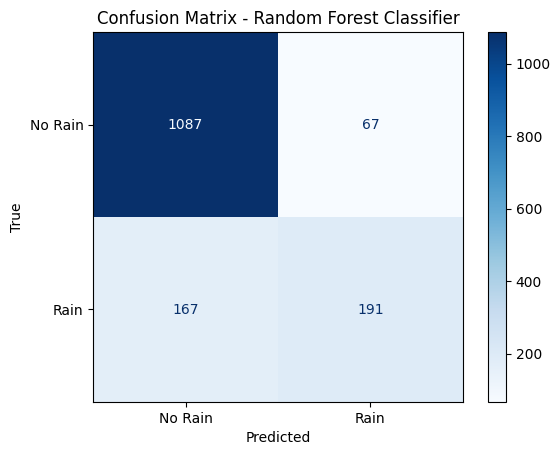

Confusion matrix saved to: ../reports/figures/confusion_matrix.png


In [18]:
cm = confusion_matrix(y_test, y_pred, labels=["No", "Yes"])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Rain", "Rain"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest Classifier")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.grid(False)

# Save the figure
fig_dir = "../reports/figures/"
os.makedirs(fig_dir, exist_ok=True)
cm_path = os.path.join(fig_dir, "confusion_matrix.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Confusion matrix saved to: {cm_path}")

### What does this matrix reveal?

- The model is **very good at predicting "No Rain"** (high specificity).
- It **struggles more with "Rain"**, missing a non‑trivial number of rainy days (lower recall).
- This typically means the model is **conservative**:  
  it only predicts "Rain" when it is very confident.

Depending on the business context:

- If missing a rainy day is **very costly** (e.g. logistics disruptions),  
  we might want to **increase recall** for the "Rain" class, even if it increases false alarms.

## 5. Predicted probability distribution

We analyze the distribution of predicted probabilities for the **positive class** ("Rain").

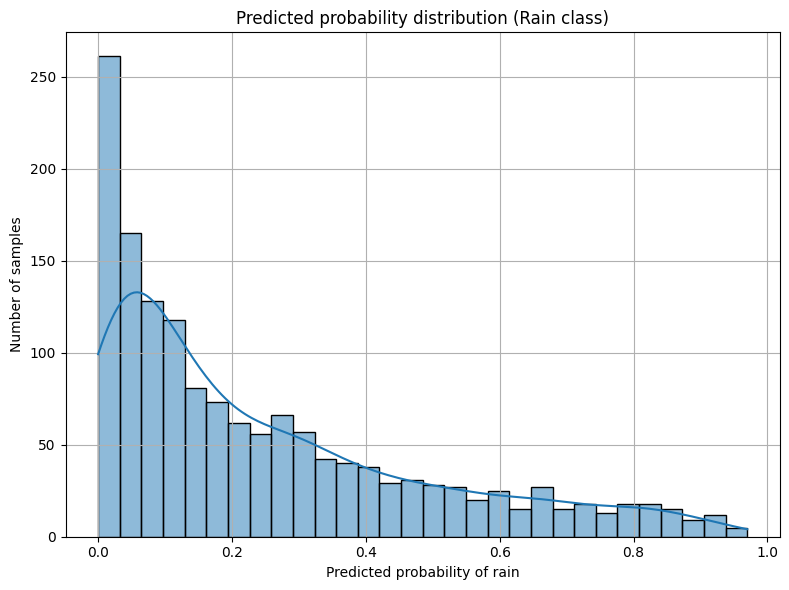

Probability distribution plot saved to: ../reports/figures/predicted_probability_distribution.png


In [19]:
plt.figure(figsize=(8, 6))
sns.histplot(y_prob, bins=30, kde=True)
plt.title("Predicted probability distribution (Rain class)")
plt.xlabel("Predicted probability of rain")
plt.ylabel("Number of samples")
plt.grid(True)

proba_path = os.path.join(fig_dir, "predicted_probability_distribution.png")
plt.savefig(proba_path, dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

print(f"Probability distribution plot saved to: {proba_path}")

### What does this graph show?

- Many predictions are **concentrated near 0** for the "No Rain" class,  
  which is expected and desirable: the model is confident on many dry days.
- For rainy days, a significant fraction of samples receive relatively **low predicted probabilities** (e.g. < 0.4),  
  even when it actually rained.  

This explains the lower recall for the "Rain" class:

- The model often assigns *some* probability of rain,  
  but not enough to cross the default **0.5 decision threshold**,
  so those days are predicted as "No Rain".

One potential refinement is to **adjust the decision threshold** (e.g. 0.4 instead of 0.5)  
to trade off more false positives for better detection of rainy days.

The model is very hesitant when predicting rain, and only does so when it is very certain. This results in low recall for the "Rain" class, as we saw in the confusion matrix. This graph clearly confirms this.

## 6. Feature importance

We now inspect which features the Random Forest model considers most important.

Since we are using a pipeline with one‑hot encoding, we need to:

1. Extract the underlying classifier (`best_model["classifier"]`).
2. Retrieve the transformed feature names (numeric + one‑hot categorical).
3. Combine them with the feature importance scores.

In [20]:
# Retrieve feature importances from the best estimator
rf = best_model["classifier"]
feature_importances = rf.feature_importances_

# Rebuild numeric and categorical feature lists on the training data
numeric_features = X_train.select_dtypes(include=["float", "int"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Get one-hot encoded feature names
ohe = best_model["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
ohe_feature_names = list(ohe.get_feature_names_out(categorical_features))

# Combine numeric and categorical feature names
feature_names = numeric_features + ohe_feature_names

len(feature_names), len(feature_importances)

(81, 81)

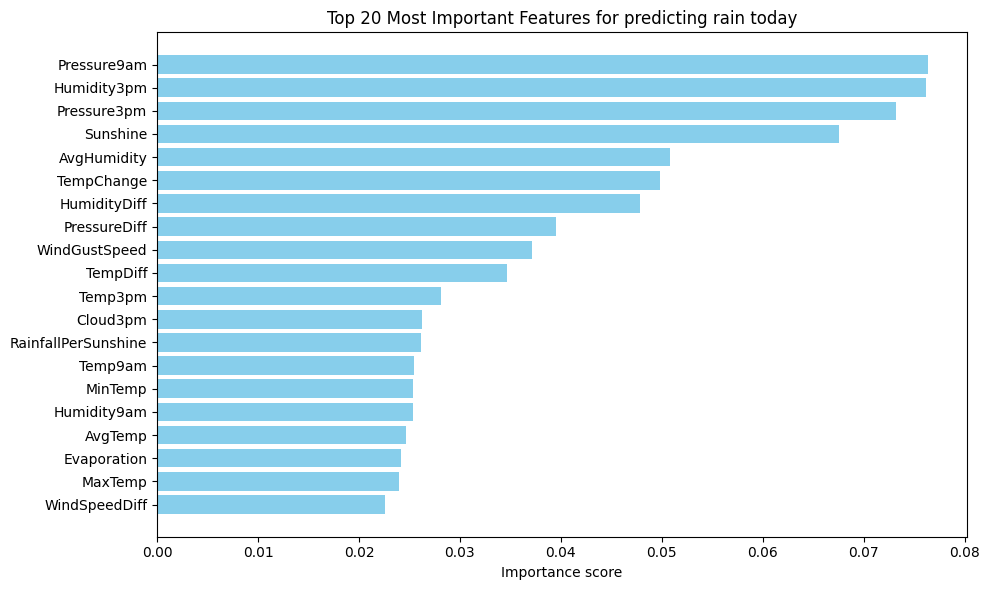

Feature importance plot saved to: ../reports/figures/feature_importance.png


In [21]:
# Create a DataFrame with feature importances
importance_df = (
    pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": feature_importances,
        }
    )
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

N = 20
top_features = importance_df.head(N)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"], color="skyblue")
plt.gca().invert_yaxis()  # Most important feature on top
plt.title(f"Top {N} Most Important Features for predicting rain today")
plt.xlabel("Importance score")

fi_path = os.path.join(fig_dir, "feature_importance.png")
plt.savefig(fi_path, dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

print(f"Feature importance plot saved to: {fi_path}")

The plot highlights the **top 20 features** driving the model’s decisions.

Typically, we expect:

- Humidity‑related features (`Humidity3pm`, `AvgHumidity`, `HumidityDiff`),
- Rainfall measures (`Rainfall`, `RainfallPerSunshine`),
- Temperature at key times (`Temp3pm`, `AvgTemp`),
- Seasonality / location encodings,

to appear among the most important predictors.

This helps:

- Validate that the model is learning **physically meaningful patterns**,
- Identify candidates for **feature selection** or further engineering.

## 7. Final conclusions and potential refinements

Overall, the model:

- Achieves **solid performance** (Accuracy ~85–86%, ROC–AUC ~0.90),
- Is **very strong at predicting "No Rain"**,
- Has **room for improvement** in detecting rainy days (lower recall on "Rain" class).

Possible refinements include:

1. **Decision threshold tuning**

   - Instead of using a fixed 0.5 threshold,  
     choose a threshold that optimizes a metric of interest (e.g. recall or F1 for "Rain").

2. **Class imbalance handling**

   - Use `class_weight="balanced"` in the Random Forest,
   - Try oversampling/undersampling techniques (e.g. SMOTE) on the training set.

3. **Feature selection / regularization**

   - Remove highly redundant features (strongly correlated but not adding value),
   - Focus on the most important features to simplify the model.

4. **Trying alternative models**

   - Gradient Boosting (e.g. XGBoost, LightGBM, HistGradientBoosting),
   - Regularized Logistic Regression for a more interpretable baseline.

5. **Richer evaluation**

   - Calibration plots for predicted probabilities,
   - Cost‑sensitive metrics aligned with business impact (e.g. higher penalty for missing rainy days).

Even without these refinements, this Random Forest pipeline already provides a **well‑balanced and practically useful model** for predicting daily rain in the Melbourne area.


<br>

<hr>

## Author

<a href="https://www.linkedin.com/in/flavio-aguirre-12784a252/">**Flavio Aguirre**</a>  
<a href="https://coursera.org/share/e27ae5af81b56f99a2aa85289b7cdd04">***Data Scientist***</a>
